In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
df = wine.frame
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print("Shape of dataset:", df.shape)

print("\nData Types:")
print(df.dtypes)
print("\nStatistical Summary:")
df.describe()

Shape of dataset: (178, 14)

Data Types:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Statistical Summary:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


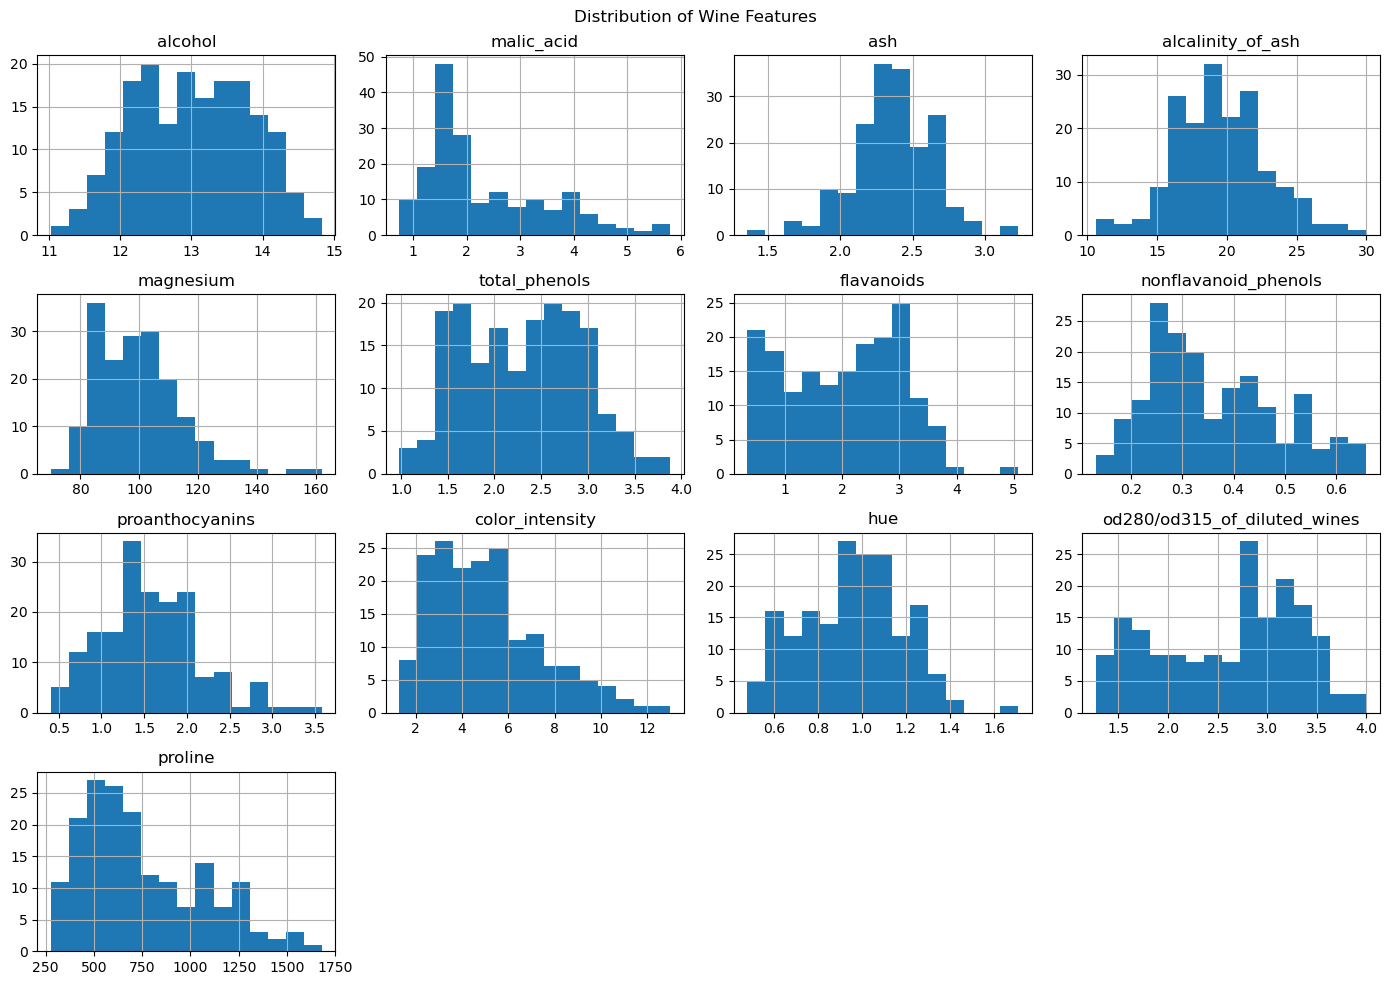

In [5]:
df[wine.feature_names].hist(figsize=(14, 10), bins=15)
plt.suptitle("Distribution of Wine Features")
plt.tight_layout()
plt.show()

In [6]:
X = df[wine.feature_names]
y = df["target"]
print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

Input feature shape: (178, 13)
Target shape: (178,)


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=wine.feature_names)
X_scaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [10]:
from sklearn.decomposition import PCA 
pca = PCA() 
X_pca = pca.fit_transform(X_scaled)
print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (178, 13)
PCA shape: (178, 13)


In [13]:
explained_variance = pca.explained_variance_ratio_
# explained_variance 
# explained_variance_df =  
explained_variance_df = pd.DataFrame({
"Principal Component": range(1, len(explained_variance) + 1),
"Explained Variance Ratio": explained_variance,
"Explained Variance (%)": explained_variance * 100
})
explained_variance_df

,Principal Component,Explained Variance Ratio,Explained Variance (%)
0,1,0.361988,36.198848
1,2,0.192075,19.207490
2,3,0.111236,11.123631
3,4,0.070690,7.069030
4,5,0.065633,6.563294
5,6,0.049358,4.935823
6,7,0.042387,4.238679
7,8,0.026807,2.680749
8,9,0.022222,2.222153
9,10,0.019300,1.930019


In [14]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cumulative_variance_df = pd.DataFrame({
"Number of Components": range(1, len(cumulative_variance) + 1),
"Cumulative Explained Variance": cumulative_variance,
"Cumulative Explained Variance (%)": cumulative_variance * 100
})
cumulative_variance_df 

,Number of Components,Cumulative Explained Variance,Cumulative Explained Variance (%)
0,1,0.361988,36.198848
1,2,0.554063,55.406338
2,3,0.665300,66.529969
3,4,0.735990,73.598999
4,5,0.801623,80.162293
5,6,0.850981,85.098116
6,7,0.893368,89.336795
7,8,0.920175,92.017544
8,9,0.942397,94.239698
9,10,0.961697,96.169717


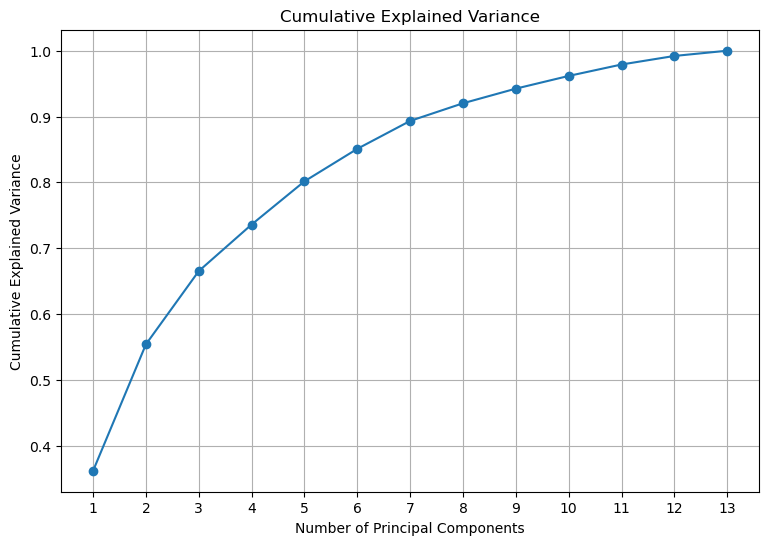

In [15]:
plt.figure(figsize=(9, 6))
plt.plot(
range(1, len(cumulative_variance) + 1),
cumulative_variance,
marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)
plt.show() 

In [16]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("Number of components required for 95% variance:",
n_components_95)
print("Variance retained:",
cumulative_variance[n_components_95 - 1] * 100, "%")

Number of components required for 95% variance: 10
Variance retained: 96.16971684450641 %


In [17]:
pca_reduced = PCA(n_components=n_components_95)
X_reduced = pca_reduced.fit_transform(X_scaled)
print("Original data shape:", X_scaled.shape)
print("Reduced data shape:", X_reduced.shape)

Original data shape: (178, 13)
Reduced data shape: (178, 10)


In [18]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
pca_2d_df = pd.DataFrame(
X_pca_2d,
columns=["PC1", "PC2"]
)
pca_2d_df["Target"] = y.values
pca_2d_df.head()

,PC1,PC2,Target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0
